#### Building chatbot with multiple tools

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
arxiv.invoke("What are the latest papers on deep learning?")

'Published: 2023-01-03\nTitle: Deep Learning and Computational Physics (Lecture Notes)\nAuthors: Deep Ray, Orazio Pinti, Assad A. Oberai\nSummary: These notes were compiled as lecture notes for a course developed and taught at the University of the Southern California. They should be accessible to a typical engineering graduate student with a strong background in Applied Mathematics.\n  The main objective of these notes is to introduce a student who is familiar with concepts in linear algebra and par'

In [4]:
wiki_wrapper = WikipediaAPIWrapper()
wikipedia = WikipediaQueryRun(api_wrapper=wiki_wrapper)
wikipedia.invoke("What is machine learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML finds application in many fields, including natural language processing, computer vision, speech recognition, email filtering, agriculture, and medicine. The application of ML to business problems is known as predictive analytics.\nStatistics and mathematical optimisation (mathematical programming) methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom a theoretical viewpoint,

In [11]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()
tavily.invoke("Provide me the latest news on India galgotiyan university?")

[{'title': 'Galgotias University booted from India AI Impact summit ...',
  'url': 'https://apnews.com/article/india-ai-chinese-galgotias-university-robotic-dog-850acd70109cae9ae34c2b78923b2cbb',
  'content': 'AP Logo\n\nCopyright 2026 The Associated Press. All Rights Reserved.\n\nAP Logo\n\nCopyright 2026 The Associated Press. All Rights Reserved.\n\n# A robotic dog made in China gets an Indian university kicked out of an AI summit\n\n## A robotic dog made in China gets an Indian university kicked out of an AI summit\n\nPeople visit Galgotias University stall at AI summit ahead of an eviction order issued by Indian authorities, in New Delhi, India, Wednesday, Feb. 18, 2026. (AP Photo)\n\nPeople visit Galgotias University stall at AI summit ahead of an eviction order issued by Indian authorities, in New Delhi, India, Wednesday, Feb. 18, 2026. (AP Photo)\n\nVisitors stand next to an advertising billboard at AI summit in New Delhi, India, Wednesday, Feb. 18, 2026. (AP Photo) [...] Visito

In [12]:
# Combine all the tools in the list
tools = [arxiv, wikipedia, tavily]


In [13]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.1-8b-instant", groq_api_key = groq_api_key)
llm_with_tools = llm.bind_tools(tools)

In [17]:
from pprint import pprint
from langchain_core.messages import HumanMessage,AIMessage
llm_with_tools.invoke("What is the latest news on India galgotiyan university? Also, provide me the latest papers on deep learning and a brief overview of machine learning.")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8qhtpj8pj', 'function': {'arguments': '{"query":"India Galgotiya University latest news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'g0jsrbvws', 'function': {'arguments': '{"query":"deep learning recent papers"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': 'kjfsre303', 'function': {'arguments': '{"query":"machine learning"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 577, 'total_tokens': 632, 'completion_time': 0.068281801, 'completion_tokens_details': None, 'prompt_time': 0.03188241, 'prompt_tokens_details': None, 'queue_time': 0.0454081, 'total_time': 0.100164211}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c8078-b80d-7692-bd87-708059cd9edb-0', tool_calls=[{'nam

In [18]:
llm_with_tools.invoke("What is the latest news on India galgotiyan university? Also, provide me the latest papers on deep learning and a brief overview of machine learning.").tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'India Galgotias University latest news'},
  'id': '9agaahrmj',
  'type': 'tool_call'},
 {'name': 'arxiv',
  'args': {'query': 'deep learning'},
  'id': 'dyaj0rcbs',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'machine learning overview'},
  'id': 'rs9b225wy',
  'type': 'tool_call'}]

In [20]:
# State schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [21]:
def tool_calling_llm(state:State):
    return {"messages" : llm_with_tools.invoke(state["messages"])}

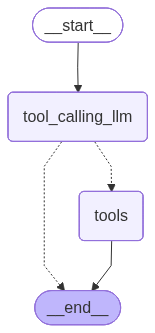

In [28]:
# Entire chatbot with langgraph
from IPython.display import display,Image
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
graph = StateGraph(State)
# Adding the nodes to the graph
graph.add_node("tool_calling_llm",tool_calling_llm)
graph.add_node("tools",ToolNode(tools))
# adding edges to the graph
graph.add_edge(START,"tool_calling_llm")

graph.add_conditional_edges("tool_calling_llm",tools_condition)
graph.add_edge("tools",END)

graph_builder = graph.compile()
visualise_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(visualise_graph))




In [29]:
messages = graph_builder.invoke({"messages":[HumanMessage(content="What is the latest news on India galgotiyan university? Also, provide me the latest papers on deep learning and a brief overview of machine learning.")]})
for i in messages["messages"]:
    i.pretty_print()

================================ Human Message =================================

What is the latest news on India galgotiyan university? Also, provide me the latest papers on deep learning and a brief overview of machine learning.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (4vcv4h56x)
 Call ID: 4vcv4h56x
  Args:
    query: India galgotiyan university latest news
  arxiv (pez67tzmq)
 Call ID: pez67tzmq
  Args:
    query: deep learning papers 2024
  wikipedia (yaf3qge8t)
 Call ID: yaf3qge8t
  Args:
    query: machine learning overview
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Galgotias University booted from India AI Impact summit over robot ...", "url": "https://apnews.com/article/india-ai-chinese-galgotias-university-robotic-dog-850acd70109cae9ae34c2b78923b2cbb", "content": "AP Logo\n\nCopyright 2026 The Associated Press. A